In [ ]:
import matplotlib.pyplot as plt
import numpy as np



plt.style.use('../my_style.mplstyle')

r = 0.59
d = 0.025
dna = 0.010

f = 1.13e-2

k_cargo = 2.26e-2
v = 0.5
tau = d/v

def dna_potential_gaussian(f, x, r):
    r_a = np.sqrt(2 * r * d / (1 + d/r)**2)
    cutoff = np.sqrt((d+2*dna)*(2*r+2*dna))/(1+(2*dna+d/2)/r)
    epsilon = np.sqrt(np.exp(1)/2) * r_a * f 
    if np.abs(x) <= cutoff:
        return -epsilon * np.exp(-(x**2)/(r_a**2))
    else:
        return 0

def dna_force_gaussian(f, x, r):
    r_a = np.sqrt(2 * r * d / (1 + d/r)**2)
    cutoff = np.sqrt((d+2*dna)*(2*r+2*dna))/(1+(2*dna+d/2)/r)
    epsilon = np.sqrt(np.exp(1)/2) * r_a * f 
    if np.abs(x) <= cutoff:
        return -2 * epsilon * x * np.exp(-(x**2)/(r_a**2)) / (r_a**2)
    else:
        return 0

coefficient = tau / (k_cargo * d)

#print("Coefficient:", epsilon*coefficient)

distances = np.linspace(0, 1.0, 1000)

fig, ax = plt.subplots()

ax.plot(distances, [dna_potential_gaussian(f*coefficient, x, 0.5) for x in distances], label='0.5')
ax.plot(distances, [dna_potential_gaussian(f*coefficient, x, 5.0) for x in distances], label='5.0')

ax.set_xlabel('Distance $\\tilde{r}_\mathrm{ci}$')
ax.set_ylabel('potential')
#ax.set_ylim(-1.1*f*coefficient, 0.1)
ax.legend()
plt.show()
"""
fig.savefig('figures/dna_potential_gaussian.png', bbox_inches='tight')
fig.savefig('figures/dna_potential_gaussian.pdf', bbox_inches='tight')
"""

In [ ]:
def dna_force_gaussian(f, x, r):
    r_a = np.sqrt(2 * r * d / (1 + d/r)**2)
    cutoff = np.sqrt((d+2*dna)*(2*r+2*dna))/(1+(2*dna+d/2)/r)
    epsilon = np.sqrt(np.exp(1)/2) * r_a * f 
    if np.abs(x) <= cutoff:
        return -2 * epsilon * x * np.exp(-(x**2)/(r_a**2)) / (r_a**2)
    else:
        return 0

coefficient = tau / (k_cargo * d)

#print("Coefficient:", epsilon*coefficient)

distances = np.linspace(0, 1.0, 1000)

fig, ax = plt.subplots()

ax.plot(distances, [dna_force_gaussian(f*coefficient, x, 0.5) for x in distances], label='0.5')
ax.plot(distances, [dna_force_gaussian(f*coefficient, x, 5.0) for x in distances], label='5.0')

ax.set_xlabel('force')
ax.set_ylabel('potential')
#ax.set_ylim(-1.1*f*coefficient, 0.1)
ax.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

plt.style.use('../my_style.mplstyle')

r = 0.59
d = 0.025
l = 0.010
r_a = np.sqrt(2 * r * d / (1 + d/r)**2)
r_dna = np.sqrt((d+2*l)*(2*r+2*l))/(r*(1+(2*l+d/2)/r))

f = 1.13e-2
epsilon = np.sqrt(np.exp(1)/2) * r_a * f 

k_cargo = 2.26e-2
v = 0.5
tau = r/v

In [ ]:
def dna_force_gaussian(epsilon, r, r_a):
    return -2 * epsilon * r * np.exp(-(r**2)/(r_a**2)) / (r_a**2)

def dna_force(f, r, r_a):
    if r < r_a:
        return -f
    else:
        return 0.0

def dna_force_spring(f, r, r_a, r_dna):
    if r < r_a:
        return -f
    elif r_a <= r < r_dna:
        return -f * (r_dna - r) / (r_dna - r_a)
    else:
        return 0.0
    
def spring_force(f, r, r_a):
    if r < r_a:
        return -f * r/r_a
    else:
        return 0

def Lennard_force(epsilon, r, sigma):
    return -4 * epsilon * ((-12 * (sigma**12) / (r**13)) + (6 * (sigma**6) / (r**7)))



LJ_e = (13/144) * ((26/7)**(7/6)) * r_a * f

coefficient = tau / (k_cargo * r)

print("Coefficient:", f*coefficient)

distances = np.linspace(0, 1.0, 500)

fig, ax = plt.subplots()

ax.plot(distances, [dna_force(f*coefficient, r, r_a) for r in distances], label='Step')
#ax.plot(distances, [dna_force_spring(f*coefficient, r, r_a, r_dna) for r in distances], label='DNA spring')
ax.plot(distances, [spring_force(f*coefficient, r, r_a) for r in distances], label='Linear spring')
ax.plot(distances, [dna_force_gaussian(epsilon*coefficient, r, r_a) for r in distances], label='Gaussian')

LJ_distances = distances[distances > r_a*0.9]

ax.plot(LJ_distances, [Lennard_force(LJ_e*coefficient, r, r_a) for r in LJ_distances], label='Lennard-Jones')

ax.axvline(r_a, color='black', lw=1, ls='--')
#ax.axvline(r_dna, color='black', lw=1, ls='--')

ax.text(r_a + 0.02, -1.07*f*coefficient, '$\\tilde{r}_\mathrm{a}$')
#ax.text(r_dna + 0.02, -f*coefficient, '$\hat{r}_\mathrm{dna}$')

ax.set_xlabel('Distance $\\tilde{r}_\mathrm{ci}$')
ax.set_ylabel('$F\\tau/R k_c$')
ax.set_ylim(-1.1*f*coefficient, 0.1)
ax.legend()
plt.show()

fig.savefig('../figures/dna_force_comparison.png', bbox_inches='tight')
fig.savefig('../figures/dna_force_comparison.pdf', bbox_inches='tight')

In [ ]:
def dna_force_gaussian(epsilon, r, r_a):
    return -epsilon * np.exp(-(r**2)/(r_a**2))

def dna_force(f, r, r_a):
    if r < r_a:
        return f * (r-r_a)
    else:
        return 0.0

def dna_force_spring(f, r, r_a, r_dna):
    if r < r_a:
        return -f
    elif r_a <= r < r_dna:
        return -f * (r_dna - r) / (r_dna - r_a)
    else:
        return 0.0
    
def spring_force(f, r, r_a):
    if r < r_a:
        return f * (r-r_a)**2/(2*r_a)
    else:
        return 0

def Lennard_force(epsilon, r, sigma):
    return 4 * epsilon * (((sigma**12) / (r**12)) - ((sigma**6) / (r**6)))



LJ_e = (13/144) * ((26/7)**(7/6)) * r_a * f

coefficient = tau / (k_cargo * r)

print("Coefficient:", f*coefficient)

distances = np.linspace(0, 1.0, 500)

fig, ax = plt.subplots()

ax.plot(distances, [dna_force(f*coefficient, r, r_a) for r in distances], label='Step')
#ax.plot(distances, [dna_force_spring(f*coefficient, r, r_a, r_dna) for r in distances], label='DNA spring')
ax.plot(distances, [spring_force(f*coefficient, r, r_a) for r in distances], label='Linear spring')
ax.plot(distances, [dna_force_gaussian(epsilon*coefficient, r, r_a) for r in distances], label='Gaussian')

ax.plot(distances, [Lennard_force(LJ_e*coefficient, r, r_a) for r in distances], label='Lennard-Jones')

ax.axvline(r_a, color='black', lw=1, ls='--')
#ax.axvline(r_dna, color='black', lw=1, ls='--')

ax.text(r_a + 0.02, -0.19, '$\\tilde{r}_\mathrm{a}$')
#ax.text(r_dna + 0.02, -f*coefficient, '$\hat{r}_\mathrm{dna}$')

ax.set_xlabel('Distance $\\tilde{r}_\mathrm{ci}$')
ax.set_ylabel('Potential $\\tilde{U}$')
ax.set_ylim(-0.2, 0.1)
ax.legend()
plt.show()

fig.savefig('../figures/dna_force_comparison.png', bbox_inches='tight')
fig.savefig('../figures/dna_force_comparison.pdf', bbox_inches='tight')


In [ ]:
def dna_force_gaussian(epsilon, r, r_a, cutoff):
    if r - r_a <= cutoff:
        return -2 * epsilon * r * np.exp(-(r**2)/(r_a**2)) / (r_a**2)
    else:
        return 0

coefficient = tau / (k_cargo * r)

print("Coefficient:", f*coefficient)

distances = np.linspace(0, 1.0, 500)

fig, ax = plt.subplots()

ax.plot(distances, [dna_force(f*coefficient, r, r_a) for r in distances], label='Step')

ax.axvline(r_a, color='black', lw=1, ls='--')
#ax.axvline(r_dna, color='black', lw=1, ls='--')

ax.text(r_a + 0.02, -1.07*f*coefficient, '$\\tilde{r}_\mathrm{a}$')
#ax.text(r_dna + 0.02, -f*coefficient, '$\hat{r}_\mathrm{dna}$')

ax.set_xlabel('Distance $\\tilde{r}_\mathrm{ci}$')
ax.set_ylabel('$F\\tau/R k_c$')
ax.set_ylim(-1.1*f*coefficient, 0.1)
ax.legend()
plt.show()

fig.savefig('../figures/dna_force_comparison.png', bbox_inches='tight')
fig.savefig('../figures/dna_force_comparison.pdf', bbox_inches='tight')

[(-1.5, 0.1)]

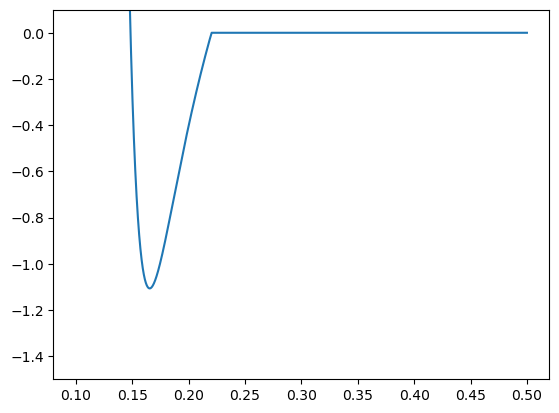

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def LJ(r, epsilon, sigma):
    return 4 * epsilon * (((sigma**12) / (r**12)) - ((sigma**6) / (r**6)))

def dot_LJ(r, epsilon, sigma):
    return -4 * epsilon * ((-12 * (sigma**12) / (r**13)) + (6 * (sigma**6) / (r**7)))

def LJ_fs(r, epsilon, sigma, r_cut):
    # np.where を用いて配列に対応
    return np.where(r <= r_cut, 
                    LJ(r, epsilon, sigma) - LJ(r_cut, epsilon, sigma) - (r-r_cut) * dot_LJ(r_cut, epsilon, sigma), 
                    0)

radius = 0.59
d=0.025
l=0.01

r = np.linspace(1e-1, 0.5, 50000) # 0割りを回避するために0より少し大きい値から開始
r_0 = np.sqrt(2 * radius * d / (1+d/(2*radius))**2)
r_cut = np.sqrt((d+2*l) * (2*radius+2*l) / (1+(2*l+d/2)/radius)**2) 

fig, ax = plt.subplots()
ax.plot(r, LJ_fs(r, 1, r_0*(2**(-1/6)), r_cut))

ax.set(ylim = (-1.5, 0.1))

[(-8.0, 1.0)]

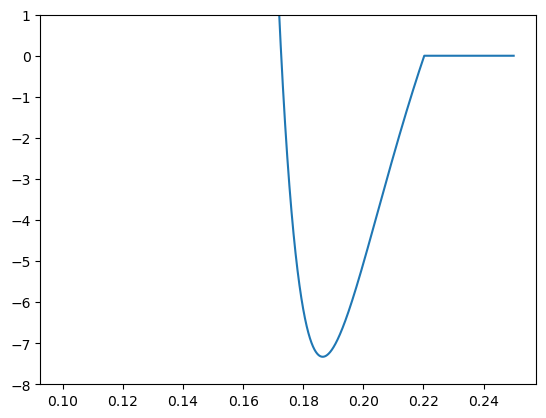

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def LJ(r, epsilon, sigma):
    return 4 * epsilon * (((sigma**12) / (r**12)) - ((sigma**6) / (r**6)))

def dot_LJ(r, epsilon, sigma):
    return -4 * epsilon * ((-12 * (sigma**12) / (r**13)) + (6 * (sigma**6) / (r**7)))

def LJ_fs(r, epsilon, sigma, r_cut):
    # np.where を用いて配列に対応
    return np.where(r <= r_cut, 
                    LJ(r, epsilon, sigma) - LJ(r_cut, epsilon, sigma) - (r-r_cut) * dot_LJ(r_cut, epsilon, sigma), 
                    0)

def dot_LJ_fs(r, epsilon, sigma, r_cut):
    # np.where を用いて配列に対応
    return np.where(r <= r_cut, 
                    dot_LJ(r, epsilon, sigma) - dot_LJ(r_cut, epsilon, sigma), 
                    0)

def dot_LJ_ts(r, epsilon, sigma, r_cut):
    # np.where を用いて配列に対応
    return np.where(r <= r_cut, 
                    dot_LJ(r, epsilon, sigma), 
                    0)

radius = 0.59
d=0.025
l=0.01

r = np.linspace(1e-1, 0.25, 50000) # 0割りを回避するために0より少し大きい値から開始
r_0 = np.sqrt(2 * radius * d / (1+d/(2*radius))**2)
r_cut = np.sqrt((d+2*l) * (2*radius+2*l) / (1+(2*l+d/2)/radius)**2) 

fig, ax = plt.subplots()
ax.plot(r, dot_LJ_fs(r, 1, r_0*(2**(-1/6)), r_cut))

ax.set(ylim = (-8, 1))

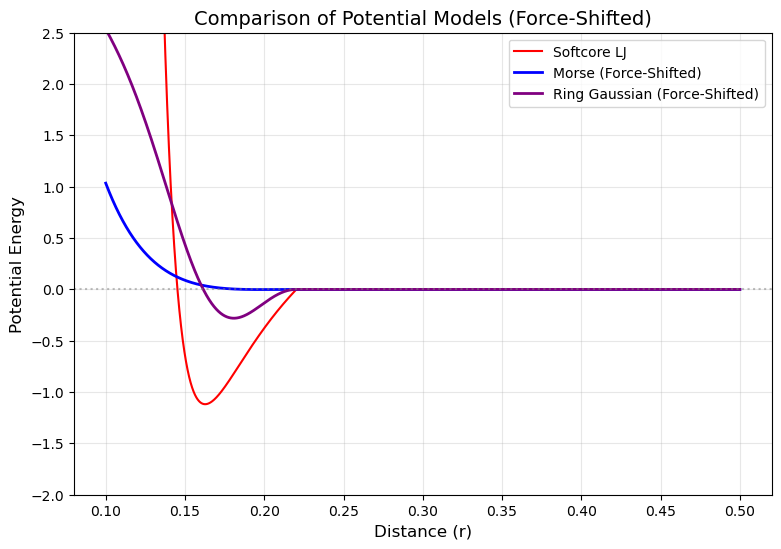

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 既存のLJ関数群（省略）
# ==========================================

# ==========================================
# 1. モース（Morse）ポテンシャル
# ==========================================
# V(r) = D_e * (1 - exp(-a * (r - r_e)))^2 - D_e
# 微分 (力): dV/dr = 2 * a * D_e * exp(-a * (r - r_e)) * (1 - exp(-a * (r - r_e)))

def Morse(r, De, a, re):
    exp_term = np.exp(-a * (r - re))
    return De * (1.0 - exp_term)**2 - De

def dot_Morse(r, De, a, re):
    exp_term = np.exp(-a * (r - re))
    return 2.0 * a * De * exp_term * (1.0 - exp_term)

def Morse_fs(r, De, a, re, r_cut):
    """カットオフ（シフト・力シフト）を施したモースポテンシャル"""
    return np.where(r <= r_cut,
                    Morse(r, De, a, re) - Morse(r_cut, De, a, re) - (r - r_cut) * dot_Morse(r_cut, De, a, re),
                    0)


# ==========================================
# 2. リング状のガウシアンポテンシャル
# ==========================================
# 特定の距離 r_ring を中心として、幅 w のガウス型の谷（結合）を作る
# V(r) = - H * exp( - (r - r_ring)^2 / (2 * w^2) )
# 微分 (力): dV/dr = H * ((r - r_ring) / w^2) * exp( - (r - r_ring)^2 / (2 * w^2) )

def Ring_Gaussian(r, H, r_ring, w):
    return -H * np.exp(- (r - r_ring)**2 / (2.0 * w**2))

def dot_Ring_Gaussian(r, H, r_ring, w):
    return H * ((r - r_ring) / w**2) * np.exp(- (r - r_ring)**2 / (2.0 * w**2))

def Ring_Gaussian_fs(r, H, r_ring, w, r_cut):
    """カットオフ（シフト・力シフト）を施したリング状ガウシアン"""
    return np.where(r <= r_cut,
                    Ring_Gaussian(r, H, r_ring, w) - Ring_Gaussian(r_cut, H, r_ring, w) - (r - r_cut) * dot_Ring_Gaussian(r_cut, H, r_ring, w),
                    0)

def LJ(r, epsilon, sigma):
    return 4 * epsilon * (((sigma**12) / (r**12)) - ((sigma**6) / (r**6)))

def dot_LJ(r, epsilon, sigma):
    return -4 * epsilon * ((-12 * (sigma**12) / (r**13)) + (6 * (sigma**6) / (r**7)))

def LJ_fs(r, epsilon, sigma, r_cut):
    return np.where(r <= r_cut, 
                    LJ(r, epsilon, sigma) - LJ(r_cut, epsilon, sigma) - (r-r_cut) * dot_LJ(r_cut, epsilon, sigma), 
                    0)

# ==========================================
# ソフトコア化した LJ ポテンシャル
# ==========================================
def LJ_soft(r, epsilon, sigma, alpha):
    r_eff = np.sqrt(r**2 + alpha**2)
    return LJ(r_eff, epsilon, sigma)

def dot_LJ_soft(r, epsilon, sigma, alpha):
    r_eff = np.sqrt(r**2 + alpha**2)
    # 合成関数の微分: dV/dr = dV/dr_eff * (r / r_eff)
    return dot_LJ(r_eff, epsilon, sigma) * (r / r_eff)

def LJ_fs_soft(r, epsilon, sigma, r_cut, alpha):
    r_cut_eff = np.sqrt(r_cut**2 + alpha**2)
    shift = LJ(r_cut_eff, epsilon, sigma)
    dot_shift = dot_LJ(r_cut_eff, epsilon, sigma) * (r_cut / r_cut_eff)
    
    return np.where(r <= r_cut,
                    LJ_soft(r, epsilon, sigma, alpha) - shift - (r - r_cut) * dot_shift,
                    0)
# ==========================================
# パラメータ設定 (追加分)
# ==========================================
radius = 0.59
d = 0.025
l = 0.01

r = np.linspace(1e-1, 0.5, 50000)
r_0 = np.sqrt(2 * radius * d / (1+d/(2*radius))**2)
r_cut = np.sqrt((d+2*l) * (2*radius+2*l) / (1+(2*l+d/2)/radius)**2) 

sigma = r_0 * (2**(-1/6))
alpha = 0.2 * sigma 

# 1. モースパラメータ (LJと似た形状になるよう調整)
De = 1       # 結合の深さ
re = r_0 * (2**(-1/6))       # 安定平衡距離 (LJの極小値付近)
a_param = 2/r_0 # 壁の硬さ

# 2. リング状ガウシアンパラメータ
H = 1.5        # 井戸の深さ
r_ring = r_0  # 最も強く結合させたい距離（リングの半径）
w = 0.03       # 結合の許容幅 (狭いほど鋭いポケットになる)

# ==========================================
# プロット
# ==========================================
fig, ax = plt.subplots(figsize=(9, 6))

# ① ソフトコアLJ (比較用)
ax.plot(r, LJ_fs_soft(r, 1, sigma, r_cut, alpha), label='Softcore LJ', color='red', linewidth=1.5)

# ② モースポテンシャル (LJに似ているが、近距離での反発が指数関数なのでLJほど急激ではない)
ax.plot(r, Morse_fs(r, De, a_param, re, r_cut), label='Morse (Force-Shifted)', color='blue', linewidth=2)

# ③ リング状ガウシアン (特定の距離だけポコッと凹む相互作用)
ax.plot(r, Ring_Gaussian_fs(r, H, r_ring, w, r_cut), label='Ring Gaussian (Force-Shifted)', color='purple', linewidth=2)

ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
#ax.set(ylim=(-2.0, 2.5))
ax.set_xlabel('Distance (r)', fontsize=12)
ax.set_ylabel('Potential Energy', fontsize=12)
ax.set_title('Comparison of Potential Models (Force-Shifted)', fontsize=14)
ax.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

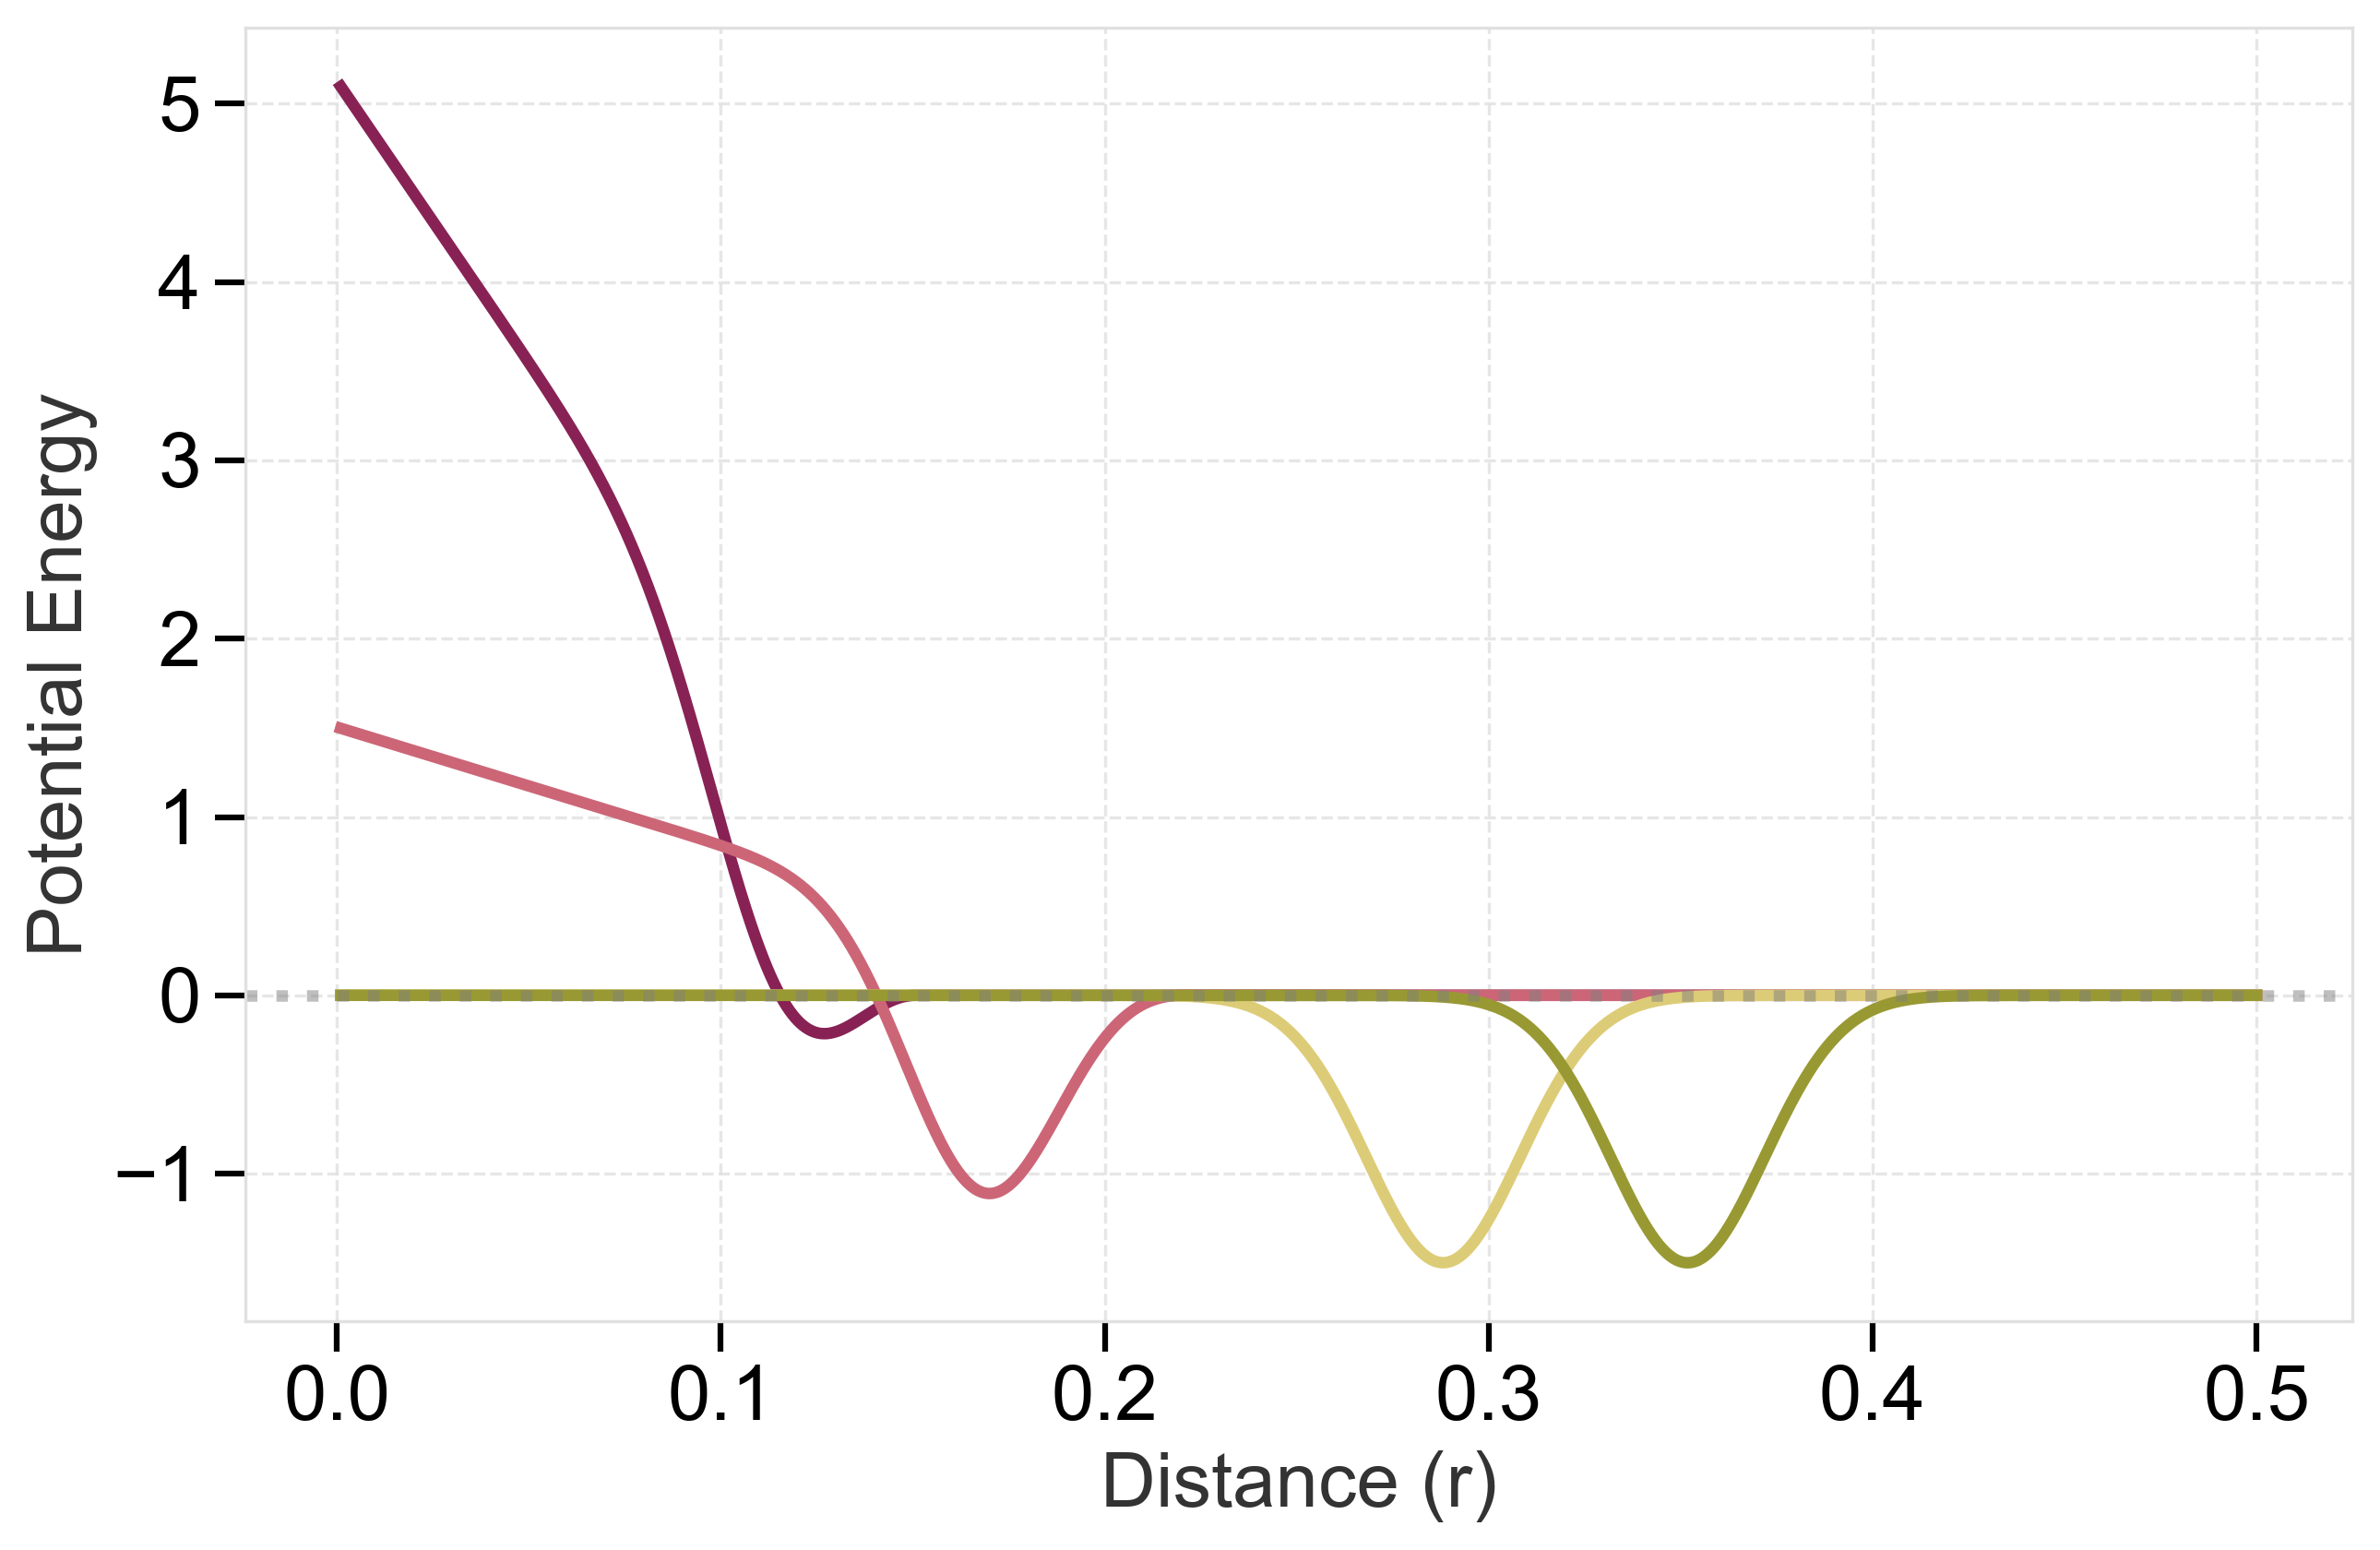

In [23]:
import numpy as np
import matplotlib.pyplot as plt

import os

plt.style.use('../my_style.mplstyle')

# ==========================================
# 既存のLJ関数群（省略）
# ==========================================

# ==========================================
# 1. モース（Morse）ポテンシャル
# ==========================================
# V(r) = D_e * (1 - exp(-a * (r - r_e)))^2 - D_e
# 微分 (力): dV/dr = 2 * a * D_e * exp(-a * (r - r_e)) * (1 - exp(-a * (r - r_e)))

def Morse(r, De, a, re):
    exp_term = np.exp(-a * (r - re))
    return De * (1.0 - exp_term)**2 - De

def dot_Morse(r, De, a, re):
    exp_term = np.exp(-a * (r - re))
    return 2.0 * a * De * exp_term * (1.0 - exp_term)

def Morse_fs(r, De, a, re, r_cut):
    """カットオフ（シフト・力シフト）を施したモースポテンシャル"""
    return np.where(r <= r_cut,
                    Morse(r, De, a, re) - Morse(r_cut, De, a, re) - (r - r_cut) * dot_Morse(r_cut, De, a, re),
                    0)


# ==========================================
# 2. リング状のガウシアンポテンシャル
# ==========================================
# 特定の距離 r_ring を中心として、幅 w のガウス型の谷（結合）を作る
# V(r) = - H * exp( - (r - r_ring)^2 / (2 * w^2) )
# 微分 (力): dV/dr = H * ((r - r_ring) / w^2) * exp( - (r - r_ring)^2 / (2 * w^2) )

def Ring_Gaussian(r, H, r_ring, w):
    return -H * np.exp(- (r - r_ring)**2 / (2.0 * w**2))

def dot_Ring_Gaussian(r, H, r_ring, w):
    return H * ((r - r_ring) / w**2) * np.exp(- (r - r_ring)**2 / (2.0 * w**2))

def Ring_Gaussian_fs(r, H, r_ring, w, r_cut):
    """カットオフ（シフト・力シフト）を施したリング状ガウシアン"""
    return np.where(r <= r_cut,
                    Ring_Gaussian(r, H, r_ring, w) - Ring_Gaussian(r_cut, H, r_ring, w) - (r - r_cut) * dot_Ring_Gaussian(r_cut, H, r_ring, w),
                    0)

# ==========================================
# パラメータ設定 (追加分)
# ==========================================
d = 0.025
l = 0.01

r = np.linspace(1e-3, 0.5, 50000)

def r_0(radius, d):
    return np.sqrt(2 * radius * d / (1+d/(2*radius))**2)

def r_cut(radius, d, l):
    return np.sqrt((d+2*l) * (2*radius+2*l) / (1+(2*l+d/2)/radius)**2) 

# 2. リング状ガウシアンパラメータ
H = 1.5        # 井戸の深さ
r_ring = r_0  # 最も強く結合させたい距離（リングの半径）
w = 2*l      # 結合の許容幅 (狭いほど鋭いポケットになる)

# ==========================================
# プロット
# ==========================================
fig, ax = plt.subplots(figsize=(9, 6))


# ③ リング状ガウシアン (特定の距離だけポコッと凹む相互作用)
ax.plot(r, Ring_Gaussian_fs(r, H, r_0(0.3, d), w, r_cut(0.3, d, l)), label='Ring Gaussian (Force-Shifted), 0.6um')

ax.plot(r, Ring_Gaussian_fs(r, H, r_0(0.59, d), w, r_cut(0.59, d, l)), label='Ring Gaussian (Force-Shifted), 1um')

ax.plot(r, Ring_Gaussian_fs(r, H, r_0(1.685, d), w, r_cut(1.685, d, l)), label='Ring Gaussian (Force-Shifted), 3um')

ax.plot(r, Ring_Gaussian_fs(r, H, r_0(2.5, d), w, r_cut(2.5, d, l)), label='Ring Gaussian (Force-Shifted), 5um')

# r_0の位置
#ax.vlines(r_0, -10, 10, color = "gray", linestyle='-.', zorder = -1)

# r_cutの位置
#ax.vlines(r_cut, -10, 10, color = "gray", linestyle='-.', zorder = -1)

ax.axhline(0, color='gray', linestyle=':', alpha=0.5)

"""ax.set(xlim=(0, 0.3),
        ylim=(-1.5, 2))"""
ax.set_xlabel('Distance (r)')
ax.set_ylabel('Potential Energy')
#ax.set_title('Comparison of Potential Models (Force-Shifted)', fontsize=14)
plt.show()

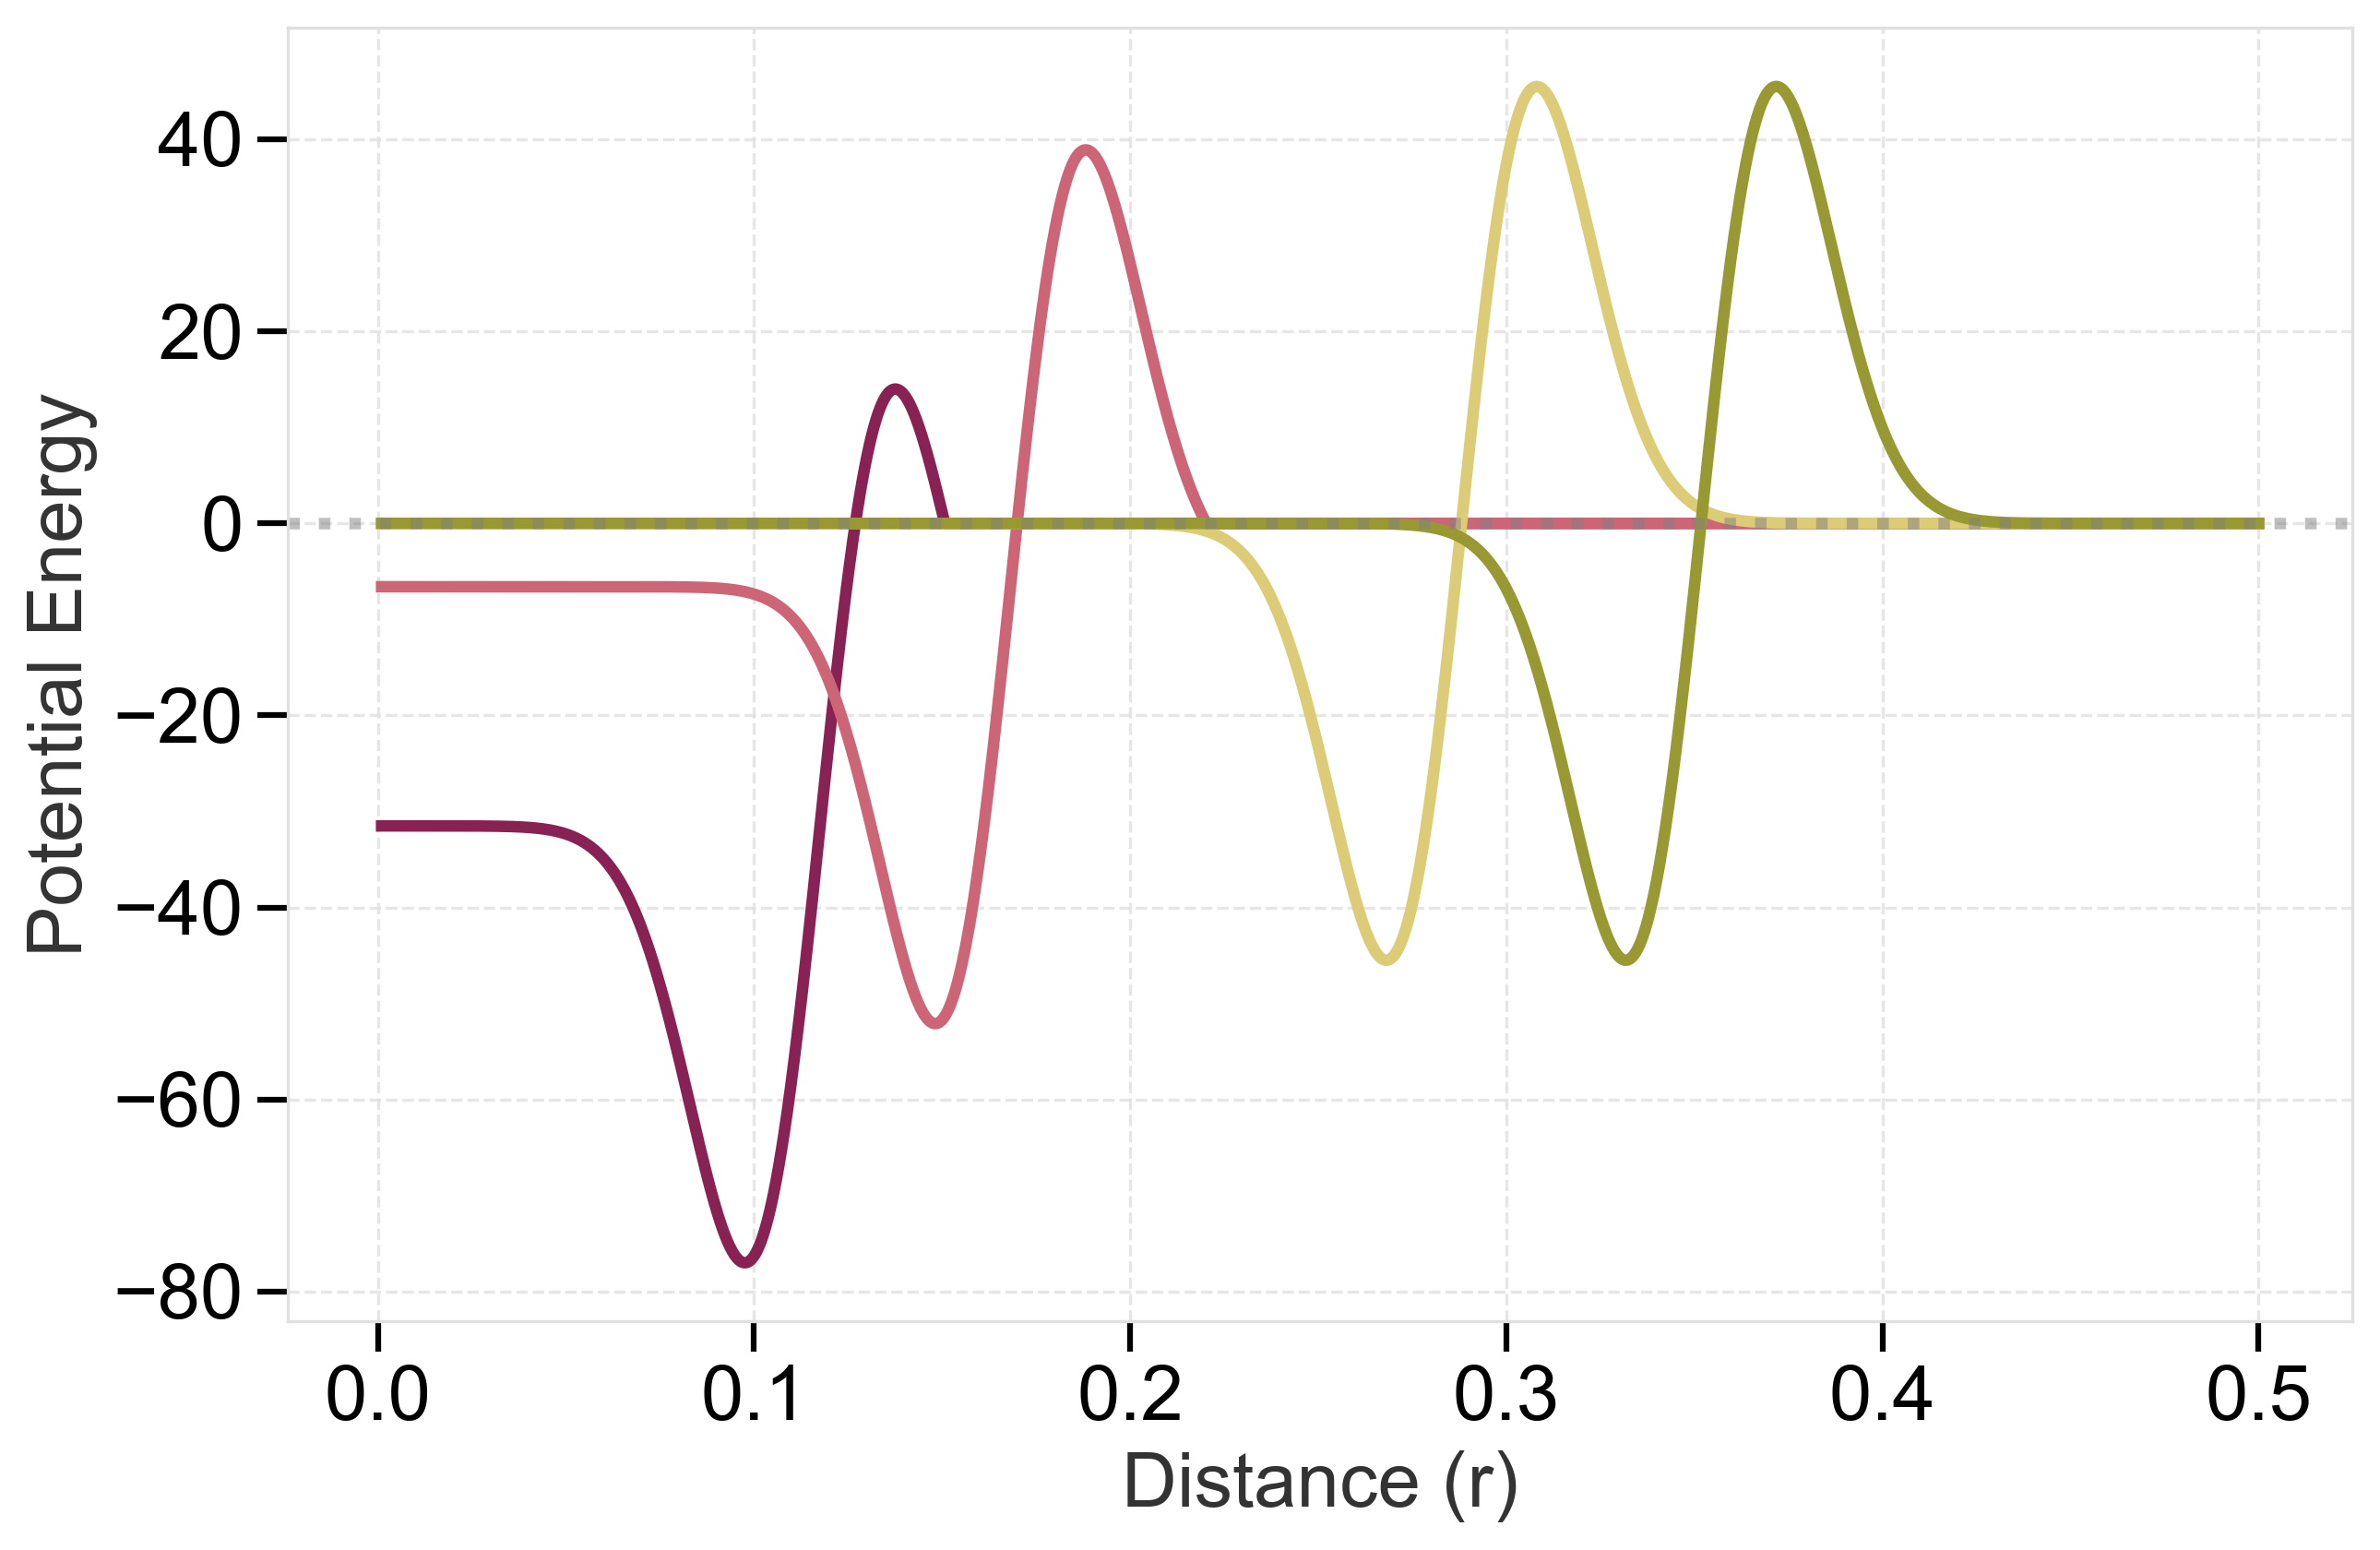

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 2. リング状のガウシアンポテンシャル
# ==========================================
# 特定の距離 r_ring を中心として、幅 w のガウス型の谷（結合）を作る
# V(r) = - H * exp( - (r - r_ring)^2 / (2 * w^2) )
# 微分 (力): dV/dr = H * ((r - r_ring) / w^2) * exp( - (r - r_ring)^2 / (2 * w^2) )

def Ring_Gaussian(r, H, r_ring, w):
    return -H * np.exp(- (r - r_ring)**2 / (2.0 * w**2))

def dot_Ring_Gaussian(r, H, r_ring, w):
    return H * ((r - r_ring) / w**2) * np.exp(- (r - r_ring)**2 / (2.0 * w**2))

def Ring_Gaussian_fs(r, H, r_ring, w, r_cut):
    """カットオフ（シフト・力シフト）を施したリング状ガウシアン"""
    return np.where(r <= r_cut,
                    Ring_Gaussian(r, H, r_ring, w) - Ring_Gaussian(r_cut, H, r_ring, w) - (r - r_cut) * dot_Ring_Gaussian(r_cut, H, r_ring, w),
                    0)

def dot_Ring_Gaussian_fs(r, H, r_ring, w, r_cut):
    """カットオフ（シフト・力シフト）を施したリング状ガウシアン"""
    return np.where(r <= r_cut,
                    dot_Ring_Gaussian(r, H, r_ring, w) - dot_Ring_Gaussian(r_cut, H, r_ring, w),
                    0)

# ==========================================
# パラメータ設定 (追加分)
# ==========================================
d = 0.025
l = 0.01

r = np.linspace(1e-3, 0.5, 50000)

def r_0(radius, d):
    return np.sqrt(2 * radius * d / (1+d/(2*radius))**2)

def r_cut(radius, d, l):
    return np.sqrt((d+2*l) * (2*radius+2*l) / (1+(2*l+d/2)/radius)**2) 

# 2. リング状ガウシアンパラメータ
H = 1.5        # 井戸の深さ
r_ring = r_0  # 最も強く結合させたい距離（リングの半径）
w = 2*l      # 結合の許容幅 (狭いほど鋭いポケットになる)

# ==========================================
# プロット
# ==========================================
fig, ax = plt.subplots(figsize=(9, 6))


# ③ リング状ガウシアン (特定の距離だけポコッと凹む相互作用)
ax.plot(r, dot_Ring_Gaussian_fs(r, H, r_0(0.3, d), w, r_cut(0.3, d, l)), label='Ring Gaussian (Force-Shifted), 0.6um')

ax.plot(r, dot_Ring_Gaussian_fs(r, H, r_0(0.59, d), w, r_cut(0.59, d, l)), label='Ring Gaussian (Force-Shifted), 1um')

ax.plot(r, dot_Ring_Gaussian_fs(r, H, r_0(1.685, d), w, r_cut(1.685, d, l)), label='Ring Gaussian (Force-Shifted), 3um')

ax.plot(r, dot_Ring_Gaussian_fs(r, H, r_0(2.5, d), w, r_cut(2.5, d, l)), label='Ring Gaussian (Force-Shifted), 5um')

# r_0の位置
#ax.vlines(r_0, -10, 10, color = "gray", linestyle='-.', zorder = -1)

# r_cutの位置
#ax.vlines(r_cut, -10, 10, color = "gray", linestyle='-.', zorder = -1)

ax.axhline(0, color='gray', linestyle=':', alpha=0.5)

"""ax.set(xlim=(0, 0.3),
        ylim=(-1.5, 2))"""
ax.set_xlabel('Distance (r)')
ax.set_ylabel('Potential Energy')
#ax.set_title('Comparison of Potential Models (Force-Shifted)', fontsize=14)
plt.show()